# Data imputation

The data is heavely unbalanced, if the nulls are deleted some classes are not even represented. In order to solve this we've used data imputation


In [23]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.compose import ColumnTransformer

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
dataset = pd.read_csv("../datasets/thyroid0387_cleanded.data", sep = ";", index_col="Unnamed: 0")

In [7]:
dataset["diagnosis_group"].value_counts()

diagnosis_group
normal                   6547
hypothyroid               572
general_health            435
replacement_therapy       336
binding_protein           324
misc                      247
hyperthyroid              189
antithyroid_treatment      33
Name: count, dtype: int64

In [8]:
dataset.dropna()["diagnosis_group"].value_counts()

diagnosis_group
normal                 15
hypothyroid             2
general_health          1
replacement_therapy     1
Name: count, dtype: int64

# Imputation of NaNs

In [9]:
dataset.dtypes

age                            int64
on_thyroxine                    bool
query_on_thyroxine              bool
on_antithyroid_medication       bool
sick                            bool
pregnant                        bool
thyroid_surgery                 bool
I131_treatment                  bool
query_hypothyroid               bool
query_hyperthyroid              bool
lithium                         bool
goitre                          bool
tumor                           bool
hypopituitary                   bool
psych                           bool
diagnosis                     object
diagnosis_group               object
sex_M                           bool
TSH_value                    float64
T3_value                     float64
TT4_value                    float64
T4U_value                    float64
FTI_value                    float64
TBG_value                    float64
ref_STMW                        bool
ref_SVHC                        bool
ref_SVHD                        bool
r

In [10]:
x = dataset.drop(columns = ["diagnosis_group"])
y = dataset["diagnosis_group"]

In [11]:
numeric_col = x.select_dtypes(include = ["int64", "float64"]).columns
categoric_col = x.select_dtypes(exclude = ["int64", "float64"]).columns

In [12]:
# SimpleImputer can't handle the Bool type, parsing to Object
x[categoric_col] = x[categoric_col].astype("object")

In [13]:
numerical_imputer = IterativeImputer(random_state = 42)
categorical_imputer = SimpleImputer(strategy = "most_frequent")

In [14]:
processor = ColumnTransformer(
    transformers = [
        ("num", numerical_imputer, numeric_col),
        ("cat", categorical_imputer, categoric_col)
    ]
)

In [15]:
x_imputed = processor.fit_transform(x)
x_imputed = pd.DataFrame(x_imputed, columns = numeric_col.tolist() + categoric_col.tolist())

C:\Users\David\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
x_imputed

,age,TSH_value,T3_value,TT4_value,T4U_value,FTI_value,TBG_value,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,...,hypopituitary,psych,diagnosis,sex_M,ref_STMW,ref_SVHC,ref_SVHD,ref_SVI,ref_WEST,ref_other
0,29.0,0.3,2.170157,108.255591,0.97449,112.487583,26.839183,False,False,False,...,False,False,-,False,False,False,False,False,False,True
1,29.0,1.6,1.9,128.0,0.974873,132.756163,24.45527,False,False,False,...,False,False,-,False,False,False,False,False,False,True
2,41.0,6.181323,1.403531,71.082308,0.670556,112.536388,11.0,False,False,False,...,False,False,-,False,False,False,False,False,False,True
3,36.0,3.339489,2.058165,106.091327,0.960828,112.204518,26.0,False,False,False,...,False,False,-,False,False,False,False,False,False,True
4,32.0,1.440623,2.501988,129.546775,1.155465,111.973831,36.0,False,False,False,...,False,False,S,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8678,56.0,6.046748,1.398079,64.0,0.83,77.0,26.549632,False,False,False,...,False,False,-,True,False,False,False,True,False,False
8679,22.0,4.259755,2.001571,91.0,0.92,99.0,24.746301,False,False,False,...,False,False,-,True,False,False,False,True,False,False
8680,69.0,6.662611,2.163284,113.0,1.27,89.0,42.353022,False,False,False,...,False,False,I,True,False,False,False,True,False,False
8681,47.0,5.193243,1.585638,75.0,0.85,88.0,25.270768,False,False,False,...,False,False,-,False,False,False,False,False,False,True


## Updating dataset

In [17]:
temp = pd.concat([x_imputed, y], axis = 1)

In [18]:
for col in dataset.columns:
    dataset[col] = temp[col]

In [19]:
dataset.dropna()["diagnosis_group"].value_counts()

diagnosis_group
normal                   6171
hypothyroid               543
general_health            416
replacement_therapy       323
binding_protein           305
misc                      239
hyperthyroid              184
antithyroid_treatment      30
Name: count, dtype: int64

In [20]:
dataset = dataset.dropna()

In [22]:
def plot_univariate_distribution(df, column, bins=30):
    fig, axs = plt.subplots(1, 2, figsize=(13, 5))

    sns.histplot(df[column].dropna(), kde=True, bins=bins, ax=axs[0], color="blue")
    axs[0].set_title(f"Histogram of {column}")
    
    sns.boxplot(x=df[column], ax=axs[1], color="orange")
    axs[1].set_title(f"Boxplot of {column}")
    
    plt.tight_layout()
    plt.show()

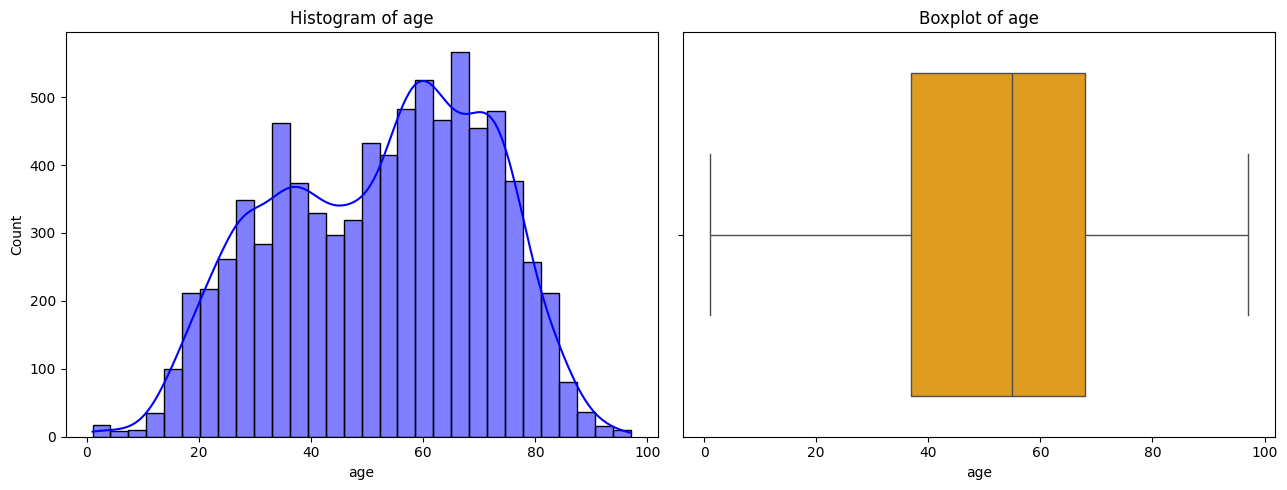

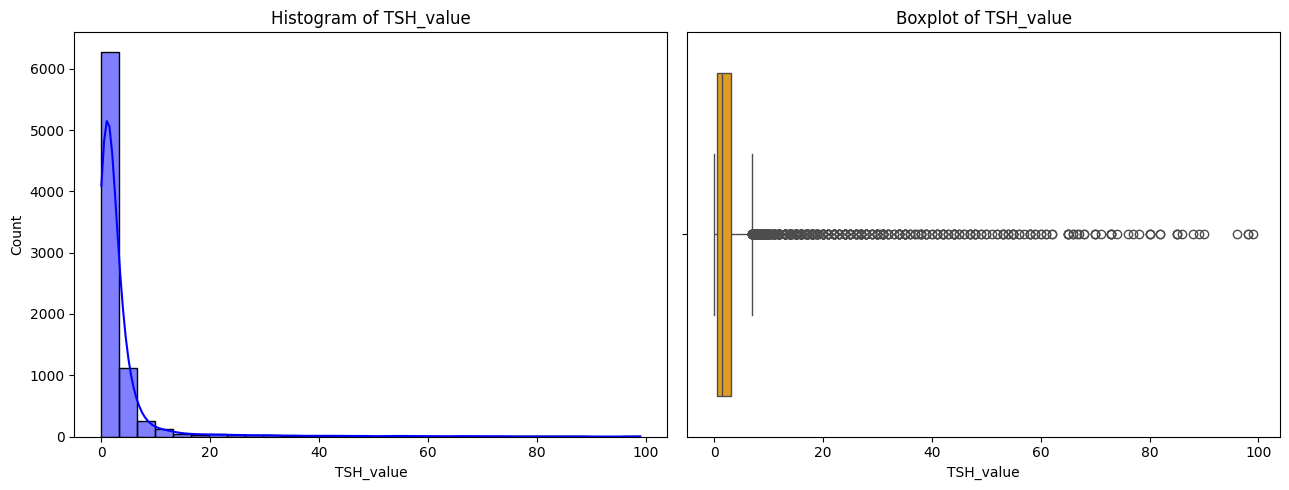

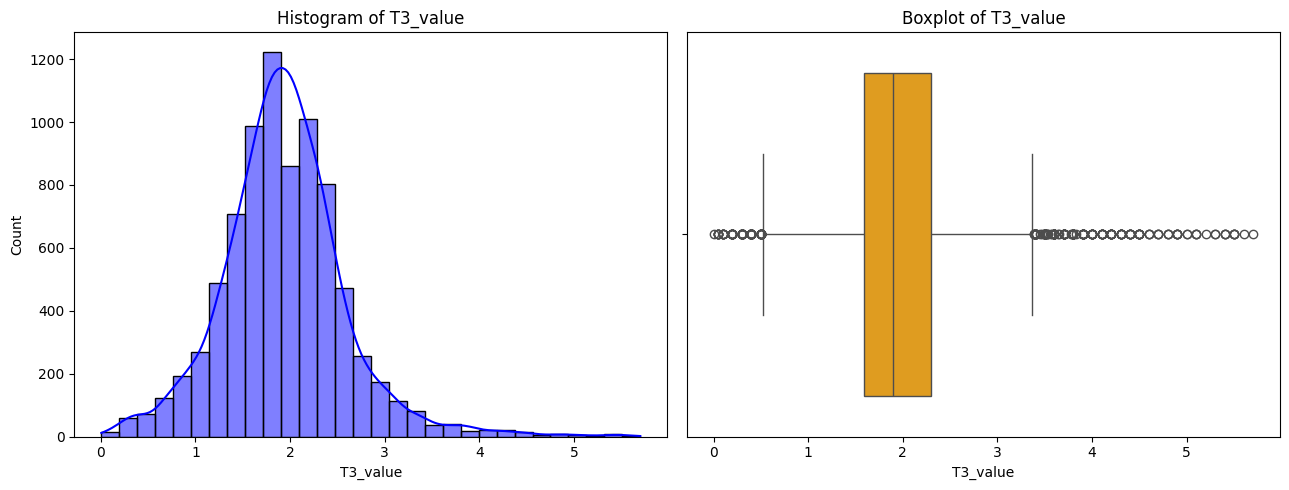

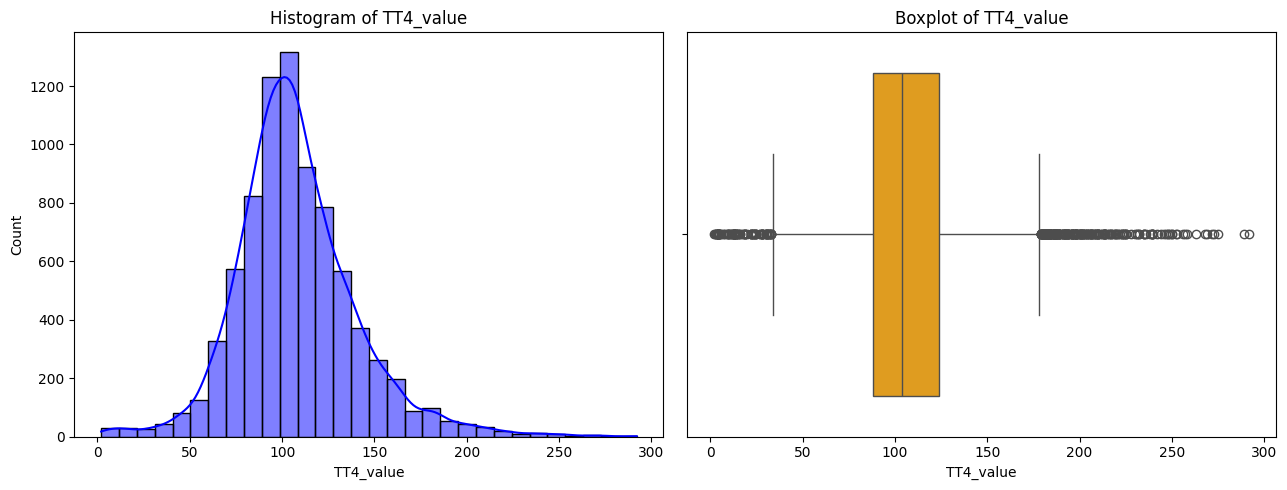

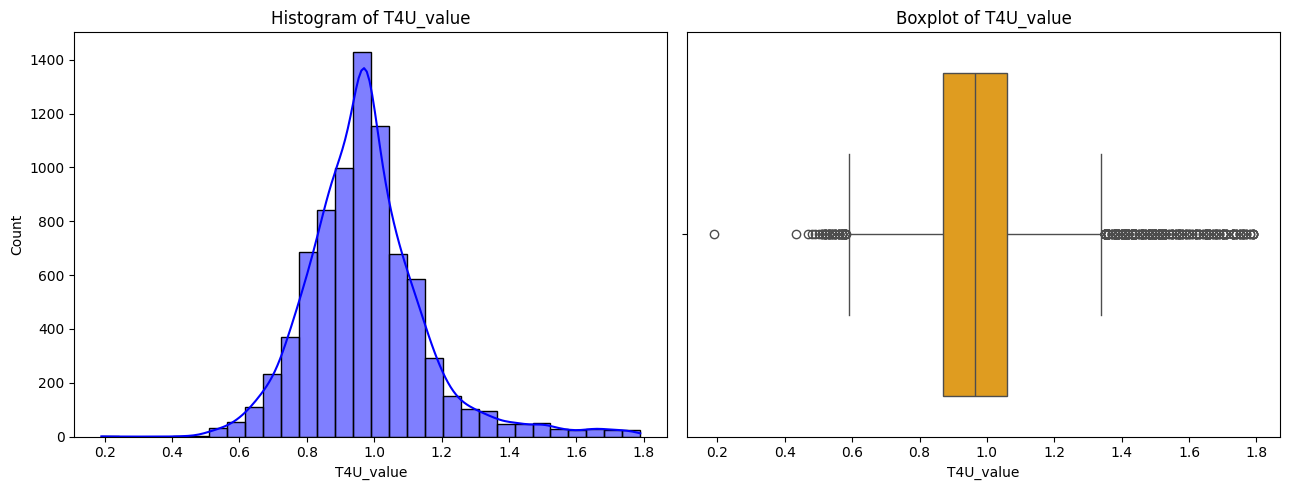

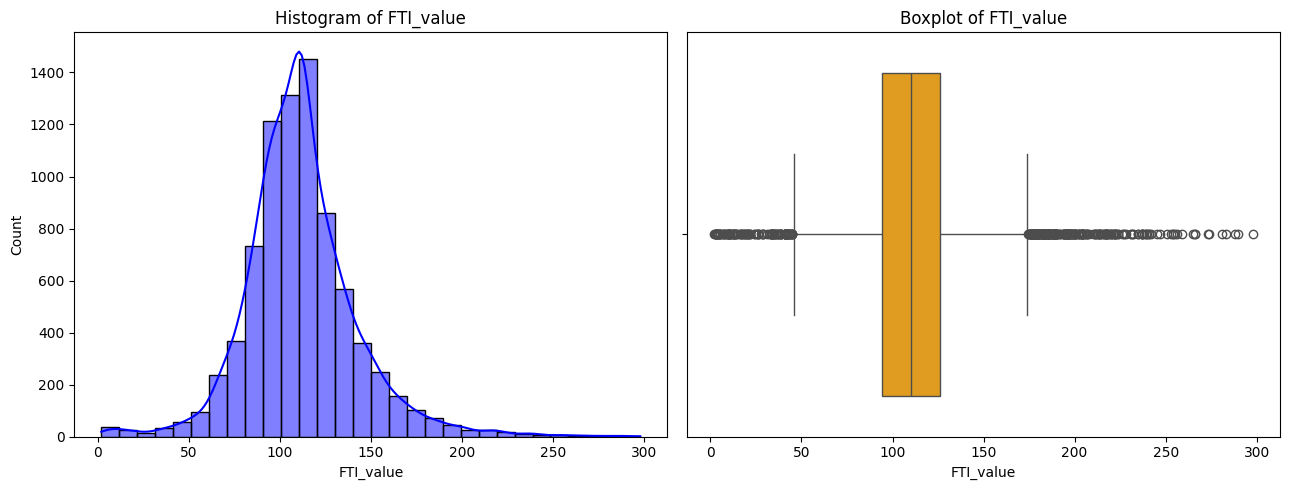

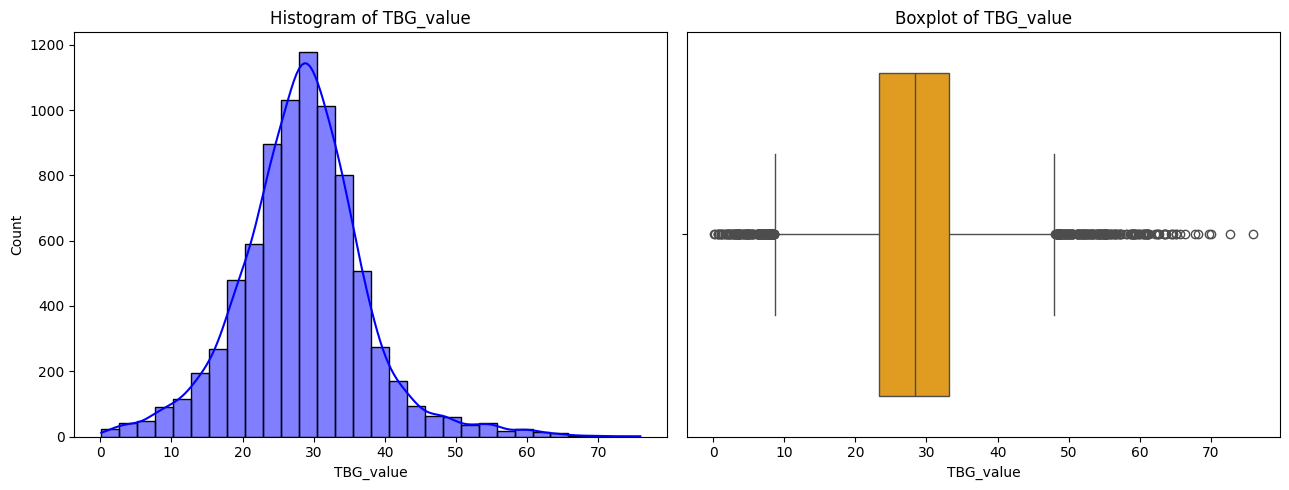

In [27]:
for col in numeric_col:
    plot_univariate_distribution(dataset, col)

In [ ]:
for col in numeric_col:
    dataset = dataset[dataset[col] >= 0]

In [28]:
dataset.to_csv("../datasets/thyroid0387_imputed.data", sep=";")